In [1]:
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [2]:
df=pd.read_csv('/content/Airline_Delay_Cause.csv')

In [3]:
df.shape

(179338, 21)

In [4]:
df['arr_del15'].isnull().sum()

np.int64(591)

In [5]:
from sklearn.impute import KNNImputer

numeric_cols = df.select_dtypes(include=np.number).columns
df_numeric = df[numeric_cols]

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df_numeric), columns=df_numeric.columns)
for col in df_imputed.columns:
    df[col] = df_imputed[col]

In [6]:
df_imputed.head()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023.0,12.0,72.0,5.0,2.46,1.00,0.73,0.0,0.81,0.0,0.0,672.0,61.0,574.0,20.0,0.0,17.0
1,2023.0,12.0,62.0,7.0,4.25,0.00,1.00,0.0,1.75,0.0,0.0,348.0,252.0,0.0,33.0,0.0,63.0
2,2023.0,12.0,95.0,10.0,5.94,0.00,1.06,0.0,3.00,0.0,0.0,859.0,536.0,0.0,47.0,0.0,276.0
3,2023.0,12.0,23.0,2.0,0.56,0.00,0.00,0.0,1.44,1.0,0.0,75.0,9.0,0.0,0.0,0.0,66.0
4,2023.0,12.0,2111.0,256.0,76.88,8.75,52.43,0.0,117.94,1.0,0.0,21424.0,8906.0,732.0,1487.0,0.0,10299.0


In [7]:
df_imputed.head()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023.0,12.0,72.0,5.0,2.46,1.00,0.73,0.0,0.81,0.0,0.0,672.0,61.0,574.0,20.0,0.0,17.0
1,2023.0,12.0,62.0,7.0,4.25,0.00,1.00,0.0,1.75,0.0,0.0,348.0,252.0,0.0,33.0,0.0,63.0
2,2023.0,12.0,95.0,10.0,5.94,0.00,1.06,0.0,3.00,0.0,0.0,859.0,536.0,0.0,47.0,0.0,276.0
3,2023.0,12.0,23.0,2.0,0.56,0.00,0.00,0.0,1.44,1.0,0.0,75.0,9.0,0.0,0.0,0.0,66.0
4,2023.0,12.0,2111.0,256.0,76.88,8.75,52.43,0.0,117.94,1.0,0.0,21424.0,8906.0,732.0,1487.0,0.0,10299.0


In [8]:
df_imputed.isnull().sum()

,0
year,0
month,0
arr_flights,0
arr_del15,0
carrier_ct,0
weather_ct,0
nas_ct,0
security_ct,0
late_aircraft_ct,0
arr_cancelled,0


In [9]:
df_imputed['is_delayed'] = (df_imputed['arr_del15'] >= 1).astype(int)

In [10]:
features = [
    'month', 'arr_flights', 'carrier_ct', 'weather_ct', 'nas_ct',
    'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted'
]
X = df_imputed[features]
y_class = df_imputed['is_delayed']
y_reg = df_imputed['arr_delay']

In [11]:
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42
)

X_train.shape, y_class_train.shape, y_reg_train.shape

((143470, 9), (143470,), (143470,))

In [12]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error

# Classification model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_scaled, y_class_train)
y_class_pred = clf.predict(X_test_scaled)

# Regression model
reg = RandomForestRegressor(random_state=42) # Changed from RandomForestClassifier to RandomForestRegressor
reg.fit(X_train_scaled, y_reg_train)
y_reg_pred = reg.predict(X_test_scaled)

In [14]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_class_test, y_class_pred)
from sklearn.metrics import f1_score, precision_score, recall_score

# y_true: true class labels
# y_pred: predicted class labels

f1 = f1_score(y_class_test, y_class_pred)
precision = precision_score(y_class_test, y_class_pred)
recall = recall_score(y_class_test, y_class_pred)

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("Accuracy:", accuracy)

F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000
Accuracy: 1.0


In [15]:
from sklearn.metrics import r2_score

r2 = r2_score(y_reg_test, y_reg_pred)
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("R2 Score:", r2)

Mean Absolute Error (MAE): 661.8892
Root Mean Squared Error (RMSE): 2082.3634
R2 Score: 0.9657919020228221


In [16]:
# Evaluation: Classification
class_report = classification_report(y_class_test, y_class_pred, output_dict=True)
conf_matrix = confusion_matrix(y_class_test, y_class_pred)

# Evaluation: Regression
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(rmse)

class_report, conf_matrix, mae, rmse

({'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 1694.0},
  '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 34174.0},
  'accuracy': 1.0,
  'macro avg': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 35868.0},
  'weighted avg': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 35868.0}},
 array([[ 1694,     0],
        [    0, 34174]]),
 661.8891820980349,
 np.float64(2082.36335884476))

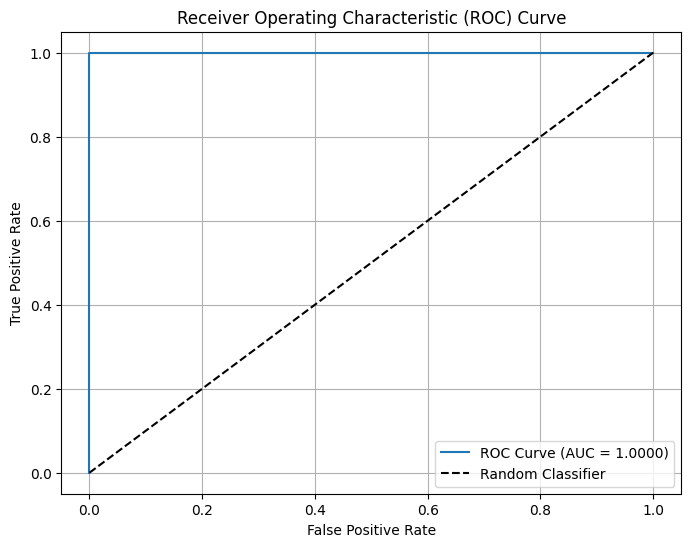

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

y_scores = clf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_class_test, y_scores)
auc_score = roc_auc_score(y_class_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [18]:
control_weights = np.array([0, 0, 1, 0, 0, 0, 1, 0, 0])
X_weighted = X * control_weights

sample_size = len(y_reg_train)

oai_pred = reg.predict(X_weighted[:sample_size])

r2_oai = r2_score(y_reg_train, oai_pred)
rmse1 = np.sqrt(mean_squared_error(y_reg_train, oai_pred))
oai_score = np.mean(np.abs(y_reg_train - oai_pred))

print(f"Root Mean Squared Error (RMSE): {rmse1:.4f}")
print("R2 Score (OAI-focused):", r2_oai)
print(f"OAI-focused Weighted MAE (lower is better): {oai_score:.2f}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


Root Mean Squared Error (RMSE): 136764.6981
R2 Score (OAI-focused): -127.88337478407624
OAI-focused Weighted MAE (lower is better): 81748.97


In [19]:
import shap

explainer = shap.Explainer(clf, X_train_scaled)
shap_values = explainer(X_test_scaled)

 99%|===================| 71129/71736 [01:39<00:00]       

<Figure size 640x480 with 0 Axes>

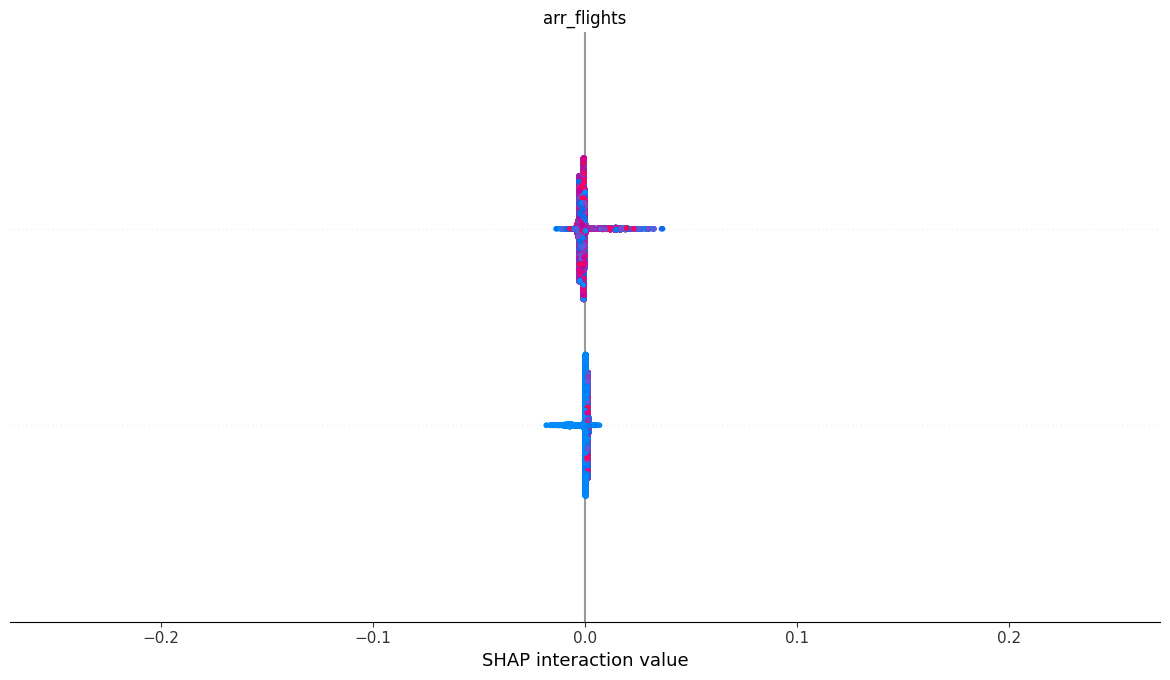

In [20]:
shap.summary_plot(shap_values, features=X_test_scaled, feature_names=features)

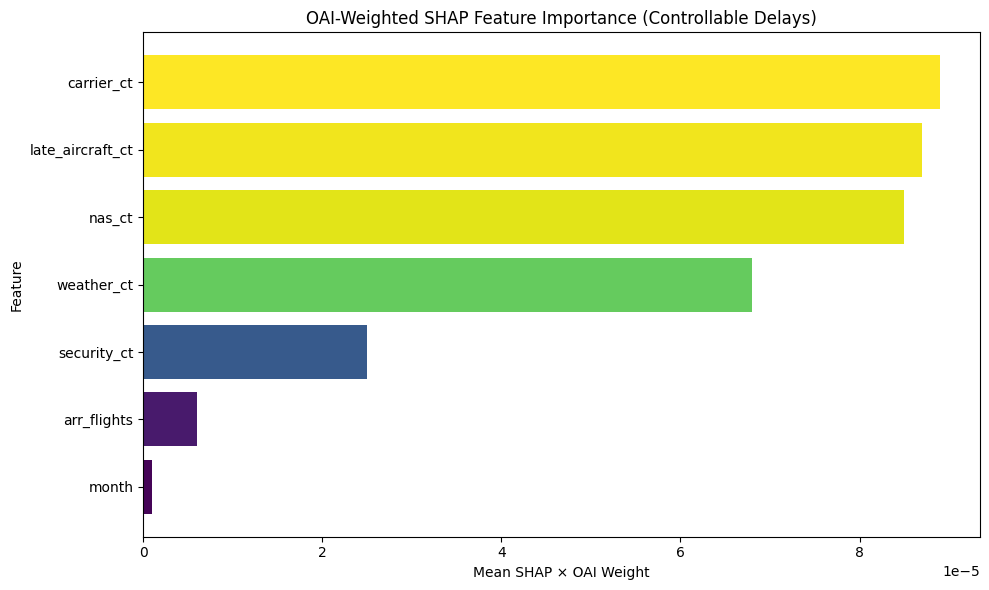

In [28]:
data = {
    'feature': [
        'carrier_ct', 'late_aircraft_ct', 'nas_ct', 'weather_ct',
        'security_ct', 'arr_flights', 'month'
    ],
    'mean_shap_oai_weight': [
        8.9e-5, 8.7e-5, 8.5e-5, 6.8e-5, 2.5e-5, 0.6e-5, 0.1e-5
    ]
}

df = pd.DataFrame(data)
df = df.sort_values(by='mean_shap_oai_weight', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df['feature'], df['mean_shap_oai_weight'], color=plt.cm.viridis(df['mean_shap_oai_weight'] / max(df['mean_shap_oai_weight'])))

plt.xlabel("Mean SHAP × OAI Weight")
plt.ylabel("Feature")
plt.title("OAI-Weighted SHAP Feature Importance (Controllable Delays)")
plt.tight_layout()
plt.show()
